# 02. Feature Engineering

Build features for market stress classification: portfolio volatility, VIX, yield spread, momentum.

Stress periods are defined as days when realized portfolio volatility exceeds the 75th percentile
of the full sample (a global threshold - see `reports/limitations.md` for the implications).

Features are lagged by one day relative to the label. `portfolio_vol` is both a feature and the
direct input to the stress threshold, so without the lag a classifier would just recover the
threshold rule instead of learning anything. With the lag this becomes a one-day-ahead prediction
task. The key caveat: the 20-day rolling window for `portfolio_vol` and the label window share
19 out of 20 days of returns, so the task is closer to predicting whether a high-volatility
regime persists into the next day rather than forecasting from independent information.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.features import build_feature_matrix

## Load prices and build features

In [2]:
prices = pd.read_csv('../data/raw/prices.csv', index_col=0, parse_dates=True)
print(f"Prices shape: {prices.shape}")

features = build_feature_matrix(prices)
print(f"Features shape: {features.shape}")
print(f"\nColumns: {list(features.columns)}")

Prices shape: (2142, 11)
Features shape: (2118, 5)

Columns: ['portfolio_vol', 'vix', 'yield_spread', 'momentum', 'stress']


## Stress regime distribution

In [3]:
stress_counts = features['stress'].value_counts().sort_index()
print("Stress label distribution:")
print(f"  Normal (0): {stress_counts[0]} days ({stress_counts[0]/len(features)*100:.1f}%)")
print(f"  Stress (1): {stress_counts[1]} days ({stress_counts[1]/len(features)*100:.1f}%)")

imbalance_ratio = stress_counts[0] / stress_counts[1]
print(f"\nClass imbalance ratio (normal:stress): {imbalance_ratio:.1f}:1")
print("\nNote: Class imbalance is moderate. Threshold metrics (precision, recall) will be important.")

Stress label distribution:
  Normal (0): 1588 days (75.0%)
  Stress (1): 530 days (25.0%)

Class imbalance ratio (normal:stress): 3.0:1

Note: Class imbalance is moderate. Threshold metrics (precision, recall) will be important.


## Time-series visualization

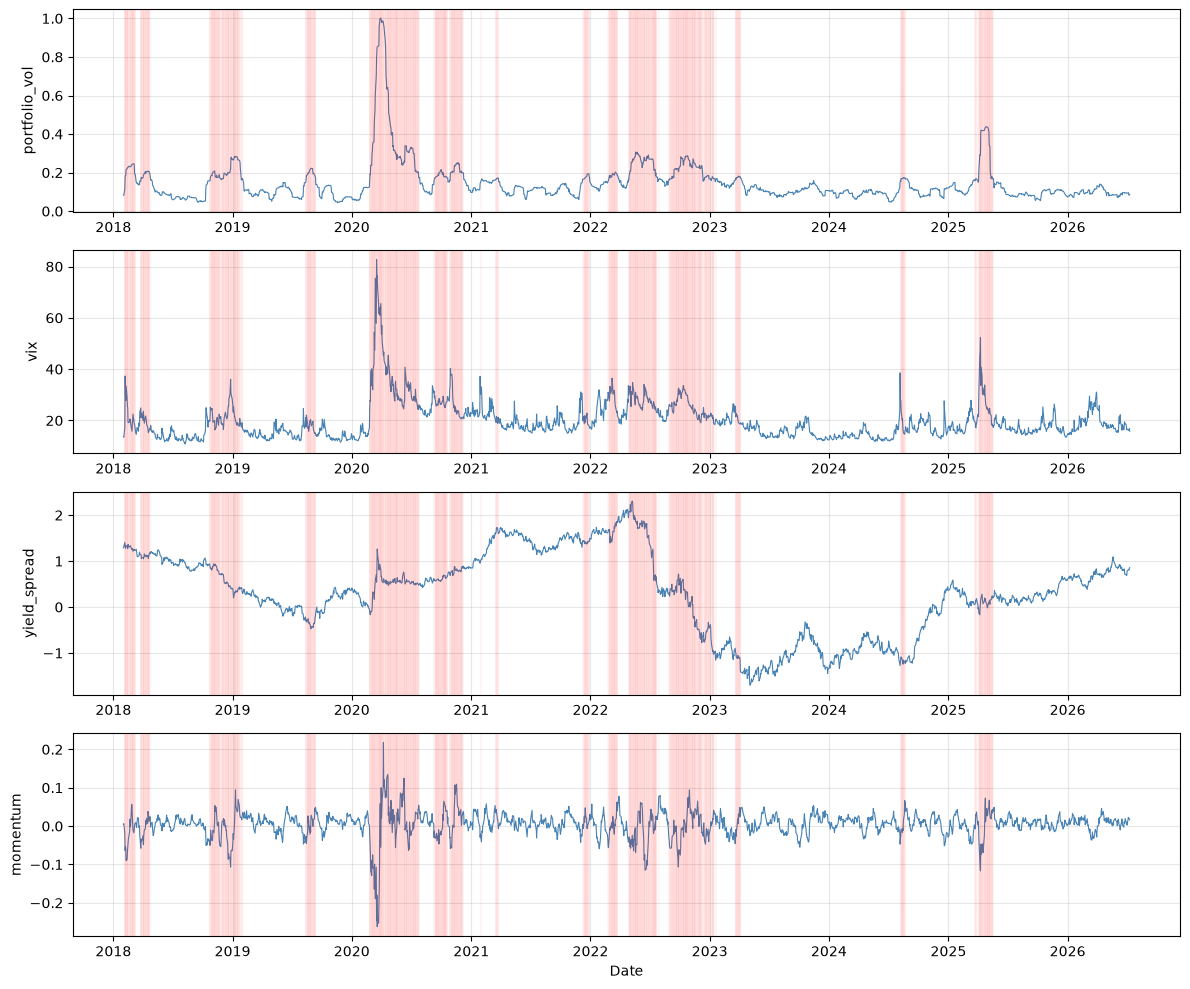

Saved figure: figures/02_feature_timeseries.png


In [4]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

for ax, col in zip(axes, ['portfolio_vol', 'vix', 'yield_spread', 'momentum']):
    ax.plot(features.index, features[col], label=col, color='steelblue', linewidth=0.8)

    # Mark individual stress days rather than spanning min-to-max, since
    # stress periods are scattered, not one contiguous block.
    stress_idx = features[features['stress'] == 1].index
    for d in stress_idx:
        ax.axvline(d, alpha=0.04, color='red')

    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.tight_layout()
plt.savefig('../figures/02_feature_timeseries.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/02_feature_timeseries.png")

## Summary statistics

In [5]:
print("Feature summary statistics:")
print(features.describe())

Feature summary statistics:
       portfolio_vol          vix  yield_spread     momentum       stress
count    2118.000000  2118.000000   2118.000000  2118.000000  2118.000000
mean        0.145995    19.813588      0.318301     0.005234     0.250236
std         0.107845     7.273083      0.882009     0.032548     0.433251
min         0.044647    10.850000     -1.704000    -0.262217     0.000000
25%         0.090086    15.080000     -0.169500    -0.007422     0.000000
50%         0.116762    17.959999      0.362500     0.008546     0.000000
75%         0.167190    22.535001      0.927500     0.021006     0.750000
max         1.001026    82.690002      2.308000     0.218165     1.000000


## Save features

In [6]:
features.to_csv('../data/processed/features.csv')
print(f"Saved to data/processed/features.csv ({features.shape[0]} rows × {features.shape[1]} columns)")

Saved to data/processed/features.csv (2118 rows × 5 columns)
